In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Instalar librerias

In [2]:
!pip install -U scikit-learn==1.6.0
!pip install nltk==3.9.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 108.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


# Procesamiento de NLP

## Explicación

`### PROPUESTA DE UN PROCESO DE KDD

-----


- Autor: Ernesto Vladimir Palacios Merino.
- Asignatura: Minería de Datos - VIU 2023
- Fecha: 15-enero-2023


#### 1. Planteamiento del problema y objetivo a alcanzar


---



Se requiere realizar la clasificación de textos cortos, de alrededor de 300 caracteres, los cuales describen las actividades realizadas diariamente por los grupos de trabajo de la Empresa Eléctrica Regional del Sur (EERSSA).

El objetivo es entrenar una red neuronal supervisada que permita la clasificación del texto contenido en las actividades diarias.

##### Contexto:

Dentro de los procesos internos de la empresa eléctrica se realiza la elaboración mensual de informes de trabajo, describiendo el tipo de trabajos y el tiempo empleado en cada uno de ellos. Esta es una tarea que se la ha venido realizando de manera manual con papel y lápiz la cual buscamos automatizar.

#### 2. Elección de la base de datos y selección de datos útiles.


---


La fuente de datos para el desarrollo del presente proyecto se trata de los informes diarios de actividades, elaborados por cada grupo de trabajo, en el cual se detalla un breve resumen de la actividad, si esta ha sido planificada o no, el sector donde se interviene y el tiempo empleado.

El origen de éstos datos es **interno** y **estructurado**. Con el objetivo de realizar la clasificación automática de estas actividad se ha digitalizado el proceso manual de calificación durante el año 2023 hasta el mes de noviembre, se cuenta entonces con un **archivo en formato excel** `2023_CALIFICACION_ACTIVIDADES.xlsx` con todas las actividades realizadas por las cuadrillas ya clasificadas.

##### Selección de datos útiles

De acuerdo con la normativa institucional, las actuvidades deben clasificarse mediante la aplicación de un código llamado Cuenta Contable.

Ésta será nuestra variable objetivo: `CUENTA`

   - `511.04.001`: Actividades en las redes de distribución (postes).
   - `511.04.002`: Actividades del alumbrado público (lámparas).
   - `511.03.003`: Actividades de líneas de transmisión (Alta Tensión ⚠️⚡)
   - `511.05.001`: Actividades de acometidas hacia el cliente final.
   - `511.05.002`: Actividades de medidores eléctricos del cliente final.
   - `521.01.001`: Actividades de comercialización del servicio eléctrico.
   - `511.06.002`: Actividades de trabajos particulares solicitados por el cliente final.
   - `OT-01-2022-GECOM`: Instalación de un nuevo medidor de energía para el cliente final.
   - `OT-07-2022-GECOM`: Restitución, cambio de un medidor de energía para el cliente final.
   - `informativo`: Es el texto que no describe ninguna actividad sino que sirve para transmitir información hacia los superiores, puede ser informar de la ausencia de un trabajador por la solicitud de un permiso, o para informar que es un día festivo y que se labora en atención de daños, etc.
























> ![2023_ACTIVIDADES.jpg](https://drive.google.com/uc?id=1sMa7_9lWB_DAQ3heILvQgwOzCy4FLmPP)

 > ##### *Captura del archivo con la fuente de datos: `2023_CALIFICACION_ACTIVIDADES.xls`*

Dentro de las actividades diarias se describen algunas como: Trasnsporte y Alimentación, las cuales no se requiere su clasificación ya que se encuentran etiquetadas en los informes diarios de los trabajadores.

Aquellas tareas de tipo informativas se las puede identificar y descartar en base a que son tareas en las que no tienen la etiqueta de la red eléctrica en la que se interviene (`ALIMENTADOR`). Solo nos interesan aquellas actividades que se realizan en las redes eléctricas.

#### 3. Procesamiento y transformación de los datos.


---


Para el desarrollo de este proceso trabajaremos con texto, por lo tanto aplicaremos las siguientes transformaciones al texto con la finalidad normalizar y generalizar la solución desarrollada.

1. Cargar el archivo de excel al entorno de python en formato de Pandas Dataframe.
2. Eliminar aquellas filas con la etiqueta de alimentación y transporte.
3. Nos quedamos solo con las columnas `Cuenta` y `Actividad`

##### Transformaciones del texto.

1. Retirar acentos (diacritics) de las palabras. (ó ➡ o, á ➡ a).
2. Convertir todos los caracteres a minúsculas.
3. Convertir abreviaciones comunmente usadas por los grupos de Trabajo y mal escritas:

        a. est     ▶ estructura
        b. trafo   ▶ transformador
        c. breiker ▶ breaker
        d. med     ▶  medidor
        e. etc...
3. Remover palabras comunes `stop words`

# ACTIVIDAD 2 - DESARROLLO DEL MODELO PLANTEADO


## 4. Modelo de Minería de Datos.

----

El modelo ha aplicar se trata de un `Clasificador` mediante `Machine Learning supervisado` ya que contamos con un dataset previamente etiquetado.

Los pasos para obtener este modelo serán:

5. Tokenización
6. Lematización (steming)
7. División la base de datos para entrenamiento y validación: 80/20
8. Vectorizar el dataset para el entrenamiento. (n_gram_range = 2)
9. Tomar las 6~10 palabras más comunmente repetidas para cada categoria.
10. Entrenamiento de la red neuronal: `Multinomial Naive Bayes : MultinomialNB()`
11. Evaluar resultados.

## 5. Discusión e interpretación de los resultados.

----

#### Parámetros a considerar / modificar:
- El paso de lematización podría resultar adverso, o necesite ajustarlo.
- Se puede hacer pruebas modificando el parámetro `n_gramas_range` en el paso de verificación, si bien son comunes las frases:
    
        a. cambio tirafusible

        b. arreglo acometida

        c. arreglo luminaria
    
    puede resultar útil modificar este parámetro.

- Analizar el vector resultante para cada categoría, identificar palabras comunes o ambiguas para ser ignoradas y verificar si esto mejora el puntaje de nuestro clasificador.

- Considerar, probar usan un `vocabulario` propio con términos que tenemos la certeza de que se usa en cada categoría en el paso de vectorización, para lu cual consideraremos aquellos que de manera programática se han detectado como comunes a cada categoría.

- Explorar otros procesamientos de lenguaje natural (word2vec) y su posible implementación al problema.

Adicional a estas consideraciones, podemos valernos de otros campos (columnas) con los que se cuenta en el documento, sería interesante combinarlo con árboles de decisión, para obtener una mejor clasificación.

## Conclusiones:

Finalmente, la necesidad de la que surge este problema es la elaboración de informes mensuales, los cuales si o si deben estar correctamente clasificados todos sus actividades, por lo cual es importante que todas las actividades esten correctamente clasificadas. Eso quiere decir que el resultado del modelo siempre será revisado y corregido, en el caso de requerirlo, por personal calificado y conocedor del tema.

Esto significa que a medida que pasen los meses, tendremos una retroalimentación al sistema y un dataset con un mayor número de datos, lo que nos permitirá explorar técnicas diferentes y evaluar sus resultados.

Al tratarse de un dataset propio y un problema personal al que se enfrenta día a día. Se llevarán a cabo todos los pasos aqui descritos, si bien no se lo pudo llegar a completar en el tiempo dado para esta actividad, se continuará con el desarrollo y solución del problema aquí propuesto.

En atención a lo mencionado, se incluye al final, luego del análisis solicitado en las actividades, a forma de `anexo`, el código desarrollado para extraer la información de las Órdenes de trabajo diarias que elabora el personal, ya que la intención y uso final de este modelo de aprendizaje es utilizarlo mes a mes en las tareas que realizan los grupos de trabajo de la zona.



----

> *Referencias:*
- [YouTube: Text Classification with Python](https://youtu.be/EfEW3_RLnGA)
- [Medium: Multinomial NB](https://medium.com/@johnm.kovachi/implementing-a-multinomial-naive-bayes-classifier-from-scratch-with-python-e70de6a3b92e)

## Carga del archivo XLSX

Se ha guardado una copia del archivo excel en Google Drive para facilitar su carga:


In [3]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1gI-6Cu2raSGqbwnd7zW6s5qC7xEpQaU1' -O "2023_ACTIVIDADES.xlsx"

--2025-11-03 17:18:58--  https://docs.google.com/uc?export=download&id=1gI-6Cu2raSGqbwnd7zW6s5qC7xEpQaU1
Resolving docs.google.com (docs.google.com)... 142.251.111.100, 142.251.111.139, 142.251.111.138, ...
Connecting to docs.google.com (docs.google.com)|142.251.111.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1gI-6Cu2raSGqbwnd7zW6s5qC7xEpQaU1&export=download [following]
--2025-11-03 17:18:58--  https://drive.usercontent.google.com/download?id=1gI-6Cu2raSGqbwnd7zW6s5qC7xEpQaU1&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.155.132, 2607:f8b0:4004:c23::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.155.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3782213 (3.6M) [application/octet-stream]
Saving to: ‘2023_ACTIVIDADES.xlsx’

2023_ACTIVIDADES.xl 100%[===================>]   3.61M  

In [4]:
# Carga del archivo en memoria.

import pandas as pd


path_actividades2023 = '/content/2023_ACTIVIDADES.xlsx'
xls_2023 = pd.ExcelFile( path_actividades2023 )
print( xls_2023.sheet_names )

['DB', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Hoja1']


La primera hoja 'DB' es una pequeña base de datos que se usa en Excel para facilitar al usuario el etiquetado de la información.

La última hoja, Hoja1, serían las actividades del mes de Diciembre, las cuales al momento de realización de este análisis no se encuentran listas en su totalidad, por lo tanto no las incluimos.

Desde Enero a  Noviembre todas las hojas tienen una estructura de columnas identicas y las que realizaremos la conversión a Dataframe para el posterior análisis.

In [5]:
df_2023 = pd.DataFrame()

for hoja in range( 1, 11, 1):
    df_2023 = pd.concat( [ df_2023, pd.read_excel( xls_2023, hoja )], ignore_index = True )

df_2023.info()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30433 entries, 0 to 30432
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CUENTA        23520 non-null  object 
 1   EVENTO        24130 non-null  object 
 2   ALIMENTADOR   29382 non-null  object 
 3   TIPO          28177 non-null  object 
 4   ACTIVIDAD     28169 non-null  object 
 5   CUADRILLA     24130 non-null  object 
 6   PRIMARIO      28177 non-null  object 
 7   FECHA INICIO  24128 non-null  object 
 8   FECHA FIN     24128 non-null  object 
 9   H:MM          24130 non-null  object 
 10  EXTRA         28137 non-null  object 
 11  DESCONEX      28169 non-null  object 
 12  ID            24130 non-null  float64
 13  RESPONSABLE   24130 non-null  object 
 14  VEHICULO      24130 non-null  object 
 15  LUGAR         24130 non-null  object 
 16  PDF           24130 non-null  object 
dtypes: float64(1), object(16)
memory usage: 3.9+ MB


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


### Analisis exploratorio 1.
Es necesario eliminar del dataset filas vacias que se importan desde excel, se eliminan las filas que no tengan texto en la columna `EVENTO`.

In [6]:
df_2023 = df_2023[df_2023.EVENTO.notnull()] #elimina filas de evento sin texto
print( "Número de filas = " + str(len(df_2023)) )
df_2023[['CUENTA','EVENTO','ALIMENTADOR','TIPO']].query( 'CUENTA == " "' ).sample(10)

Número de filas = 24130


,CUENTA,EVENTO,ALIMENTADOR,TIPO
17690,,Lunch en Yantzaza,,ALIMENTACION
10717,,AGUSTIN ALEJANDRO Y JONATHAN LUZURIAGA. DAÑO ...,,TRANSPORTE
17071,,Se ocupa hora de Lunch en Tunantza,,ALIMENTACION
25479,,Por realizar Plan de Maniobras Id: SP 1100516...,,TRANSPORTE
25819,,Traslado desde La Recta hasta la agencia El P...,,TRANSPORTE
21548,,"En Mejeche, se asiste hacia la vivienda del S...",,RUTINARIA
22324,,Retorno desde Chicaña a Yantzaza - SE LABORA:...,,TRANSPORTE
26432,,"Traslado a la Agencia Zamora - Se labora GJ, ...",,TRANSPORTE
10937,,"En la Agencia Zamora, se realiza labores admi...",,RUTINARIA
12163,,LUNCH EN ZAMORA.,,ALIMENTACION


### Análisis exploratorio 2.
Existe una gran cantidad de actividades que no tienen una cuenta asociada, esto se debe a que son actividades de tipo: transporte, alimentación, informativas. Por lo tanto presindiremos de estas actividades.

In [7]:
df_2023 = df_2023[df_2023.CUENTA != ' ']

### Análisis exploratorio 3.

Agrupamos y contamos las columna `CUENTAS` para tener una idea de los datos con los que contamos.

Observamos que hay cuatro cuentas que tienen un muy bajo conteo, esto se debe a que se tratan de tareas específicas realizadas por grupos de trabajo que no se encuentran dentro de los considerados en el área de influencia de los datos recolectados. Su existencia sugiere que se ha colaborado pero no es una tarea diaria.

El entrenar la red neuronal con una categoría ta dispareja puede ser una desventaja, una mejor alternativa puede ser el aplicar otro tipo de análisis estardístico para poder clasificar estos casos, posiblemente un árbol de decisión.

Por lo tanto guardaremos en un dataset diferente éstas cuentas con el fin de más adelante volver a realizar el proceso iterativo de KDD e integrarles a nuestro análisis.

In [8]:
print( df_2023.groupby( 'CUENTA' )['EVENTO'].nunique() )

CUENTA
511.03.003            24
511.04.001          5520
511.04.002          1718
511.05.001          1411
511.05.002          1021
521.01.001           159
OT-01-2022-GECOM     277
OT-07-2022-GECOM       8
Name: EVENTO, dtype: int64


In [9]:
"""
 Guardamos las actividades de 'baja frecuencia' en un dataset diferente.
"""

df_ActividadBajaFreq = df_2023.query( "CUENTA ==  '511.03.003' or CUENTA == '521.01.001' or CUENTA == 'OT-01-2022-GECOM' or CUENTA == 'OT-07-2022-GECOM' " )

In [10]:
"""
 Continuamos el análisis con los datos restantes.
"""

df_data = df_2023[ df_2023['CUENTA'] != '511.03.003' ][ df_2023['CUENTA'] != '521.01.001' ][ df_2023['CUENTA'] != 'OT-01-2022-GECOM' ][ df_2023['CUENTA'] != 'OT-07-2022-GECOM' ]

/tmp/ipython-input-2231369387.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_data = df_2023[ df_2023['CUENTA'] != '511.03.003' ][ df_2023['CUENTA'] != '521.01.001' ][ df_2023['CUENTA'] != 'OT-01-2022-GECOM' ][ df_2023['CUENTA'] != 'OT-07-2022-GECOM' ]
/tmp/ipython-input-2231369387.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_data = df_2023[ df_2023['CUENTA'] != '511.03.003' ][ df_2023['CUENTA'] != '521.01.001' ][ df_2023['CUENTA'] != 'OT-01-2022-GECOM' ][ df_2023['CUENTA'] != 'OT-07-2022-GECOM' ]
/tmp/ipython-input-2231369387.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_data = df_2023[ df_2023['CUENTA'] != '511.03.003' ][ df_2023['CUENTA'] != '521.01.001' ][ df_2023['CUENTA'] != 'OT-01-2022-GECOM' ][ df_2023['CUENTA'] != 'OT-07-2022-GECOM' ]


In [11]:
print( df_data.groupby( 'CUENTA' )['EVENTO'].nunique() )

CUENTA
511.04.001    5520
511.04.002    1718
511.05.001    1411
511.05.002    1021
Name: EVENTO, dtype: int64


Ahora tenemos un dataset mejor balanceado, sin embargo la cuenta `511.04.001` sigue siendo mayor a las demás,lo cual puede culminar en que se sobreaprenda esta etiqueta, para balancear de mejor manera podemos reducir los items de este tipo.

In [12]:
df_balanced = df_data.drop(df_data[df_data['CUENTA'] == '511.04.001'].sample(frac=.65).index)
df_balanced = df_balanced[df_balanced['CUENTA'].notna()]
df_balanced = df_balanced[['CUENTA','EVENTO']]
df_balanced = df_balanced.reset_index()

### Resultado de la limpieza de datos

In [13]:
print( df_balanced.groupby( 'CUENTA' )['index'].nunique() )

CUENTA
511.04.001    1946
511.04.002    1736
511.05.001    1427
511.05.002    1028
Name: index, dtype: int64


In [14]:
df_balanced.to_pickle( '/content/drive/MyDrive/Colab_Disk/NLTK/df_excel_main.pkl' )
df_ActividadBajaFreq.to_pickle( '/content/drive/MyDrive/Colab_Disk/NLTK/df_excel_gecom.pkl' )

## Cargar datos convertidos desde Excel

In [15]:
df_balanced = pd.read_pickle('/content/drive/MyDrive/Colab_Disk/NLTK/df_excel_main.pkl')
df_ActividadBajaFreq = pd.read_pickle( '/content/drive/MyDrive/Colab_Disk/NLTK/df_excel_gecom.pkl' )

## TRANSFORMACIONES DEL TEXTO

### 1. Remover acentos. (Diacritics)

> Referencia: [pandas.Series.str.normalize](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.normalize.html)

Usamos la función normalize() de Pandas para retirar los acentos.

### 2. Texto en minusculas

> Referencia: [pandas.Series.str.lower](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.lower.html)

Usamos la función lower()


### 3. Reemplazar palabras (abreviaciones)
> Referencia: [replace words in pandas using dictionary ](https://stackoverflow.com/questions/48824890/replace-words-in-pandas-dataframe-using-dictionary)





In [16]:
df_balanced['transformacion_1'] = (df_balanced['EVENTO']
                                    .str.normalize('NFKD')
                                    .str.encode('ascii', errors='ignore')
                                    .str.decode('utf-8')
                                    .str.lower()
                                    )
df_balanced.sample(10)

,index,CUENTA,EVENTO,transformacion_1
3566,21587,511.04.001,DAÑO REPORTADO POR Centro de Control San Agus...,dano reportado por centro de control san agus...
6048,30192,511.05.001,Traslado a la calle 16 de agosto se realiza R...,traslado a la calle 16 de agosto se realiza r...
972,6266,511.04.002,"En Santa Elena, Estructura 36156 se arregla l...","en santa elena, estructura 36156 se arregla l..."
1647,10314,511.05.002,"En Catacocha, Estructura 214665 se revisa el ...","en catacocha, estructura 214665 se revisa el ..."
201,735,511.04.001,En La Parroquia Tutupali se hace Plan de Mani...,en la parroquia tutupali se hace plan de mani...
3708,21841,511.04.002,"Chamico, En la Estructura No. 28774 se arregl...","chamico, en la estructura no. 28774 se arregl..."
3504,21319,511.05.001,"En Zamora, en varias calles de la Ciudad, con...","en zamora, en varias calles de la ciudad, con..."
3647,21746,511.04.002,"Quebrada de Cumbaratza, En la Estructura No. ...","quebrada de cumbaratza, en la estructura no. ..."
848,4328,511.04.001,Santa Rita Estructura 178545 se encuentra que...,santa rita estructura 178545 se encuentra que...
5269,27146,511.05.001,Traslado a Bellavista se realiza Restitucion ...,traslado a bellavista se realiza restitucion ...


In [17]:
"""
   Definición de palabras a reemplzarzar
   Esta lista se irá ampliando de manera iterativa.

"""
palabras = {
		"#"             : " ",
		"est"           : "estructura",
		"est."          : "estructura",
		"est."          : "estructura",
		"estructuras"   : "estructura",
		"poste"         : "estructura",
		"ingnitor"      : "ignitor",
		"w na"          : "wna",
		"70 w"          : "70w",
		"100 w"         : "100w",
		"150 w"         : "150w",
		"70 wna"        : "70wna",
		"70w na"        : "70wna",
		"70 w na"       : "70wna",
		"100 wna"       : "100wna",
		"100w na"       : "100wna",
		"100 w na"      : "100wna",
		"150 wna"       : "150wna",
		"150w na"       : "150wna",
		"150 w na"      : "150wna",
		"tiraf"         : "tirafusible",
		"med."          : "medidor",
		"med"           : "medidor",
		"medidores"     : "medidor",
		"cc"            : "Centro de Control",
		"cc."           : "Centro de Control",
		"cc,"           : "Centro de Control",
		"trafo"         : "transformador",
		"tranfo"        : "transformador",
		"breiker"       : "breaker",
		"  "             : " ",
	}

reemplazar = {r'(\b){}(\b)'.format(k):r'\1{}\2'.format(v) for k,v in palabras.items()}
reemplazar

{'(\\b)#(\\b)': '\\1 \\2',
 '(\\b)est(\\b)': '\\1estructura\\2',
 '(\\b)est.(\\b)': '\\1estructura\\2',
 '(\\b)estructuras(\\b)': '\\1estructura\\2',
 '(\\b)poste(\\b)': '\\1estructura\\2',
 '(\\b)ingnitor(\\b)': '\\1ignitor\\2',
 '(\\b)w na(\\b)': '\\1wna\\2',
 '(\\b)70 w(\\b)': '\\170w\\2',
 '(\\b)100 w(\\b)': '\\1100w\\2',
 '(\\b)150 w(\\b)': '\\1150w\\2',
 '(\\b)70 wna(\\b)': '\\170wna\\2',
 '(\\b)70w na(\\b)': '\\170wna\\2',
 '(\\b)70 w na(\\b)': '\\170wna\\2',
 '(\\b)100 wna(\\b)': '\\1100wna\\2',
 '(\\b)100w na(\\b)': '\\1100wna\\2',
 '(\\b)100 w na(\\b)': '\\1100wna\\2',
 '(\\b)150 wna(\\b)': '\\1150wna\\2',
 '(\\b)150w na(\\b)': '\\1150wna\\2',
 '(\\b)150 w na(\\b)': '\\1150wna\\2',
 '(\\b)tiraf(\\b)': '\\1tirafusible\\2',
 '(\\b)med.(\\b)': '\\1medidor\\2',
 '(\\b)med(\\b)': '\\1medidor\\2',
 '(\\b)medidores(\\b)': '\\1medidor\\2',
 '(\\b)cc(\\b)': '\\1Centro de Control\\2',
 '(\\b)cc.(\\b)': '\\1Centro de Control\\2',
 '(\\b)cc,(\\b)': '\\1Centro de Control\\2',
 '(\\b)trafo

#### operación de reemplazo con regex

In [18]:
df_balanced['correcciones'] = df_balanced['transformacion_1'].replace( reemplazar, regex=True)
df_balanced['correcciones'] = df_balanced['correcciones'].str.replace('[^\w\s]','',regex=True) # Remover puntuacucion . ,
df_balanced.sample(10)

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-649986604.py:2: SyntaxWarning: invalid escape sequence '\w'
  df_balanced['correcciones'] = df_balanced['correcciones'].str.replace('[^\w\s]','',regex=True) # Remover puntuacucion . ,


,index,CUENTA,EVENTO,transformacion_1,correcciones
2536,16062,511.04.001,DAÑO REPORTADO POR Centro de Control (Mensaje...,dano reportado por centro de control (mensaje...,dano reportado por centro de control mensaje ...
616,3475,511.04.002,10 La Yona Estructura No. 245498 se arregla 1...,10 la yona estructura no. 245498 se arregla 1...,10 la yona estructura no 245498 se arregla 1 ...
2731,17141,511.05.001,Revision Medidor y acometida de la Escuela El...,revision medidor y acometida de la escuela el...,revision medidor y acometida de la escuela el...
2759,17264,511.04.001,En San Antonio se retira S/O 25 metros de TX6...,en san antonio se retira s/o 25 metros de tx6...,en san antonio se retira so 25 metros de tx6 ...
4750,25193,511.04.002,En la Calle Miguel Diaz en la Estructura 3110...,en la calle miguel diaz en la estructura 3110...,en la calle miguel diaz en la estructura 3110...
691,3660,511.04.001,En Guaguayme Alto se hace desbroce de vegetac...,en guaguayme alto se hace desbroce de vegetac...,en guaguayme alto se hace desbroce de vegetac...
5974,29999,511.05.001,Barrio Los Hachos se realiza reubicacion temp...,barrio los hachos se realiza reubicacion temp...,barrio los hachos se realiza reubicacion temp...
2836,17527,511.05.001,"En Zumbi Sra. Dilma Correa, orden 4836575, se...","en zumbi sra. dilma correa, orden 4836575, se...",en zumbi sra dilma correa orden 4836575 se re...
4744,25138,511.04.001,En El Carmelo en la Estructura 38670 se encue...,en el carmelo en la estructura 38670 se encue...,en el carmelo en la estructura 38670 se encue...
382,1479,511.04.002,En Zurmi Estructura 204328 de 100 WNa (interm...,en zurmi estructura 204328 de 100 wna (interm...,en zurmi estructura 204328 de H0wna intermite...


### 4. Remover palabras comunes (stop words)
> Referencia: [remove stop words](https://www.educative.io/answers/how-to-remove-stop-words-with-nltk-library-in-python)

In [19]:
import nltk

nltk.download('stopwords')
#nltk.download('punkt')
nltk.download('punkt_tab')
stopword_es = nltk.corpus.stopwords.words('spanish')
stopword_es.append( 'estructura' ) # es comun a todas las cuentas

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [22]:
def remove_stopwords(text):
    text = [word for word in text if word not in stopword_es]
    return text

In [20]:
df_balanced['tokens'] = df_balanced['correcciones'].apply(lambda x: nltk.tokenize.word_tokenize(x))
df_balanced.sample(10)

,index,CUENTA,EVENTO,transformacion_1,correcciones,tokens
964,6225,511.05.001,DAÑO REPORTADO POR Centro de Control El 2 de ...,dano reportado por centro de control el 2 de ...,dano reportado por centro de control el 2 de ...,"[dano, reportado, por, centro, de, control, el..."
6010,30088,511.05.002,Se traslada de la Recta Pachicutza Calle Jorg...,se traslada de la recta pachicutza calle jorg...,se traslada de la recta pachicutza calle jorg...,"[se, traslada, de, la, recta, pachicutza, call..."
132,568,511.04.002,Estructura 161971 de 100W Na. (INTERMITENTE)....,estructura 161971 de 100w na. (intermitente)....,estructura 161971 de H0wna intermitente se oc...,"[estructura, 161971, de, H0wna, intermitente, ..."
2410,15646,511.04.002,En la Estructura No. 210757 se arregla 1 de 1...,en la estructura no. 210757 se arregla 1 de 1...,en la estructura no 210757 se arregla 1 de 10...,"[en, la, estructura, no, 210757, se, arregla, ..."
335,1252,511.04.001,En el Pincho en la Estructura 30863 se revisa...,en el pincho en la estructura 30863 se revisa...,en el pincho en la estructura 30863 se revisa...,"[en, el, pincho, en, la, estructura, 30863, se..."
5082,26753,511.05.001,En Yantzaza se reubica acometida y Medidor 23...,en yantzaza se reubica acometida y medidor 23...,en yantzaza se reubica acometida y medidor 23...,"[en, yantzaza, se, reubica, acometida, y, medi..."
4604,24831,511.04.002,Paquisha en la Estructura No. 37908 se arregl...,paquisha en la estructura no. 37908 se arregl...,paquisha en la estructura no 37908 se arregla...,"[paquisha, en, la, estructura, no, 37908, se, ..."
5340,27264,511.05.002,Florida se realiza inspeccion para atender co...,florida se realiza inspeccion para atender co...,florida se realiza inspeccion para atender co...,"[florida, se, realiza, inspeccion, para, atend..."
2009,12715,511.04.002,"Yantzaza barrio Bolivar Estructura 72457, se ...","yantzaza barrio bolivar estructura 72457, se ...",yantzaza barrio bolivar estructura 72457 se a...,"[yantzaza, barrio, bolivar, estructura, 72457,..."
2020,12730,511.04.002,Yantzaza barrio Pita en la Estructura No. 666...,yantzaza barrio pita en la estructura no. 666...,yantzaza barrio pita en la estructura no 6664...,"[yantzaza, barrio, pita, en, la, estructura, n..."


In [23]:
df_balanced['reduccion'] = df_balanced['tokens'].apply(lambda x: remove_stopwords(x))
df_balanced.sample(10)

,index,CUENTA,EVENTO,transformacion_1,correcciones,tokens,reduccion
4679,24984,511.04.002,"RECLAMO TECNICO. Pincho Estructura No. 30857,...","reclamo tecnico. pincho estructura no. 30857,...",reclamo tecnico pincho estructura no 30857 se...,"[reclamo, tecnico, pincho, estructura, no, 308...","[reclamo, tecnico, pincho, 30857, arregla, 1, ..."
1409,9180,511.05.002,Chamico Estructura 037359 se busca al señor J...,chamico estructura 037359 se busca al senor j...,chamico estructura 037359 se busca al senor j...,"[chamico, estructura, 037359, se, busca, al, s...","[chamico, 037359, busca, senor, jose, castillo..."
4065,23363,511.05.001,Reinspeccion del Sr. Oswaldo Guaya para reubi...,reinspeccion del sr. oswaldo guaya para reubi...,reinspeccion del sr oswaldo guaya para reubic...,"[reinspeccion, del, sr, oswaldo, guaya, para, ...","[reinspeccion, sr, oswaldo, guaya, reubicacion..."
4395,24101,511.04.001,Se Traslada Pangui est 216625 del señor Galo...,se traslada pangui est 216625 del senor galo...,se traslada pangui estructura 216625 del seno...,"[se, traslada, pangui, estructura, 216625, del...","[traslada, pangui, 216625, senor, galo, torres..."
4698,25027,511.04.002,Tambo en la Estructura No. 35882 se arregla 1...,tambo en la estructura no. 35882 se arregla 1...,tambo en la estructura no 35882 se arregla 1 ...,"[tambo, en, la, estructura, no, 35882, se, arr...","[tambo, 35882, arregla, 1, luminaria, 100, wna..."
5087,26770,511.05.002,En Zurmi se realiza reubicacion de Medidor en...,en zurmi se realiza reubicacion de medidor en...,en zurmi se realiza reubicacion de medidor en...,"[en, zurmi, se, realiza, reubicacion, de, medi...","[zurmi, realiza, reubicacion, medidor, columna..."
2368,15561,511.04.002,"En Piuntza de Guadalupe Estructura No. 38633,...","en piuntza de guadalupe estructura no. 38633,...",en piuntza de guadalupe estructura no 38633 s...,"[en, piuntza, de, guadalupe, estructura, no, 3...","[piuntza, guadalupe, 38633, arregla, 2, lumina..."
3935,22694,511.04.001,Finaliza trabajos de retensada de linea y ret...,finaliza trabajos de retensada de linea y ret...,finaliza trabajos de retensada de linea y ret...,"[finaliza, trabajos, de, retensada, de, linea,...","[finaliza, trabajos, retensada, linea, retorna..."
822,4216,511.05.002,"13 Sector Playa Zurmi, tramo Estructura 34159...","13 sector playa zurmi, tramo estructura 34159...",13 sector playa zurmi tramo estructura 341593...,"[13, sector, playa, zurmi, tramo, estructura, ...","[13, sector, playa, zurmi, tramo, 3415934145, ..."
3100,18122,511.04.002,Traslado al Ideal se atiende Reclamo se reali...,traslado al ideal se atiende reclamo se reali...,traslado al ideal se atiende reclamo se reali...,"[traslado, al, ideal, se, atiende, reclamo, se...","[traslado, ideal, atiende, reclamo, realiza, r..."


## Guardar y Cargar el Dataset balanceado

- Hasta este punto tenemos un dataset "balanceado" en las cantidades de eventos de cada cuenta.

In [24]:
df = df_balanced.reindex()
df = df[['CUENTA', 'reduccion']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6137 entries, 0 to 6136
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CUENTA     6137 non-null   object
 1   reduccion  6137 non-null   object
dtypes: object(2)
memory usage: 96.0+ KB


In [25]:
"""
    Guardamos el Archivo procesado hasta este punto en un formato PICKLE

"""

df.to_pickle( '/content/drive/MyDrive/Colab_Disk/NLTK/tokes_2023_v1.pkl' )

# IMPLEMENTACIÓN DEL MODELO:

A partir de este punto es posible implementar el/los modelos de clasificación del tipo de cuenta en base al texto descriptivo de la actividad.

Aún se necesario un mayor y mejor análisis exploratorio para contar con datos aún más precisos.

In [26]:
df = pd.read_pickle( '/content/drive/MyDrive/Colab_Disk/NLTK/tokes_2023_v1.pkl' )
df.sample(5)

,CUENTA,reduccion
4733,511.04.002,"[muchime, informacion, cliente, revisa, lumina..."
428,511.05.002,"[argelia, 37004, realiza, inspeccion, medidor,..."
39,511.04.001,"[dano, reportado, centro, control, podocarpus,..."
5525,511.04.002,"[yantzaza, barrio, sauces, 93720, arregla, 1, ..."
2848,511.05.001,"[san, vicente, chicana, sra, ana, paqui, 63279..."


### Convertir el Dataframe en Lista

In [27]:
# Unir tokens por lista

from collections import Counter

def flatten_comprehension(matrix):
    return [item for row in matrix for item in row]

df_tokens = df.groupby( 'CUENTA')['reduccion'].agg(list).reset_index(name = 'tokens' )
df_tokens['palabras'] = df_tokens['tokens'].apply( lambda token: flatten_comprehension(token) )
df_tokens = df_tokens[['CUENTA','palabras']]
df_tokens['frecuencia'] = df_tokens['palabras'].apply(Counter)
df_tokens['palabras_freq'] = df_tokens['frecuencia'].apply( lambda item: item.most_common(50) )
df_tokens[['CUENTA','palabras_freq']]

,CUENTA,palabras_freq
0,511.04.001,"[(realiza, 700), (transformador, 698), (encuen..."
1,511.04.002,"[(1, 1766), (ocupa, 1434), (luminaria, 1397), ..."
2,511.05.001,"[(medidor, 1556), (acometida, 867), (realiza, ..."
3,511.05.002,"[(medidor, 983), (servicio, 534), (breaker, 38..."


In [28]:
fila = df_tokens['frecuencia'][3]
fila.most_common(50)

[('medidor', 983),
 ('servicio', 534),
 ('breaker', 384),
 ('realiza', 320),
 ('revisa', 316),
 ('conexiones', 234),
 ('inspeccion', 231),
 ('nuevo', 223),
 ('dano', 197),
 ('encuentra', 193),
 ('cliente', 163),
 ('pangui', 127),
 ('centro', 125),
 ('cambia', 124),
 ('electrico', 120),
 ('control', 118),
 ('traslado', 118),
 ('sr', 113),
 ('ajusta', 112),
 ('normal', 108),
 ('reportado', 106),
 ('instalacion', 99),
 ('sra', 97),
 ('san', 95),
 ('nro', 92),
 ('mal', 88),
 ('ocasional', 79),
 ('traslada', 79),
 ('normaliza', 72),
 ('queda', 71),
 ('falla', 68),
 ('barrio', 67),
 ('senor', 67),
 ('atender', 64),
 ('labora', 63),
 ('voltaje', 62),
 ('zamora', 61),
 ('calle', 60),
 ('interno', 59),
 ('lectura', 58),
 ('gualaquiza', 58),
 ('reconecta', 56),
 ('acometida', 56),
 ('informa', 56),
 ('trasladamos', 56),
 ('borneras', 55),
 ('tx6', 54),
 ('c', 54),
 ('hace', 53),
 ('caja', 51)]

## Divison del set en Train y Test

In [29]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2)

## Hasta este punto hemos llegado en la transformación de los datos.

Contamos con un dataset de tokens para entrenamiento y otro para testeso de resultado, los siguientes pasos:

- vectorizer.fit
- naive_bayes_classifier
- evaluate_classifier

Quedan pendientes su implementación.

## Entrenamiento mediante NAIVE BAYES

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the tokens back into strings for vectorization
train['text'] = train['reduccion'].apply(lambda x: ' '.join(x))
test['text'] = test['reduccion'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer()

In [31]:
dtm = vectorizer.fit(train['text'])

In [33]:
from sklearn.naive_bayes import MultinomialNB

# Transform the training and testing data using the fitted vectorizer
train_vectors = vectorizer.transform(train['text'])
test_vectors = vectorizer.transform(test['text'])

# Train a Multinomial Naive Bayes classifier
classifier = MultinomialNB()
classifier.fit(train_vectors, train['CUENTA'])

MultinomialNB()

In [34]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test data
predictions = classifier.predict(test_vectors)

# Evaluate the classifier
print("Accuracy:", accuracy_score(test['CUENTA'], predictions))
print("\nClassification Report:\n", classification_report(test['CUENTA'], predictions))

Accuracy: 0.8558631921824105

Classification Report:
               precision    recall  f1-score   support

  511.04.001       0.84      0.91      0.87       382
  511.04.002       0.97      0.97      0.97       355
  511.05.001       0.73      0.86      0.79       283
  511.05.002       0.90      0.55      0.68       208

    accuracy                           0.86      1228
   macro avg       0.86      0.82      0.83      1228
weighted avg       0.86      0.86      0.85      1228



In [35]:
import pickle

# Save the trained classifier
with open('/content/drive/MyDrive/Colab_Disk/NLTK/naive_bayes_classifier.pkl', 'wb') as f:
    pickle.dump(classifier, f)

# Save the fitted vectorizer
with open('/content/drive/MyDrive/Colab_Disk/NLTK/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

## Matriz de confusión.

> PROMPT: Help me generate a confussion matrix for the trained dataset

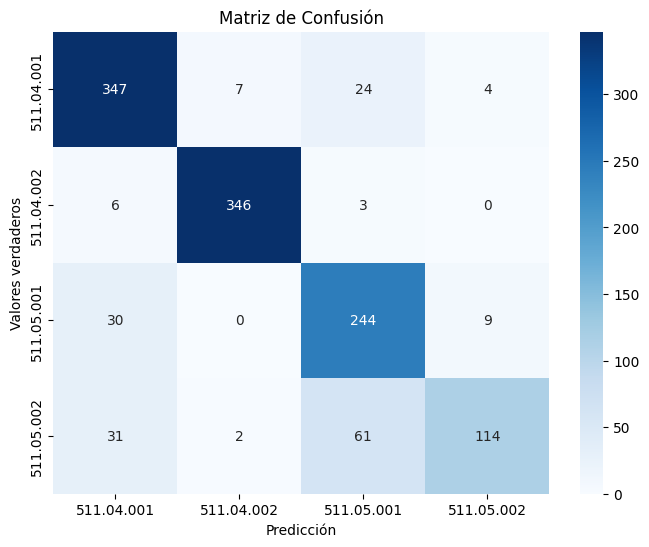

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(test['CUENTA'], predictions)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valores verdaderos')
plt.title('Matriz de Confusión')
plt.show()